In [2]:
import pandas as pd
sales_data=pd.read_csv('/content/drive/MyDrive/datasets/Sample - Superstore.csv',encoding='latin')

In [ ]:
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print(sales_data.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [ ]:
sales_data.shape

(9994, 21)

In [ ]:
sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'])

In [ ]:
forecast_data = sales_data.groupby('Order Date')['Sales'].sum().reset_index()

forecast_data.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [ ]:
forecast_data['Year'] = forecast_data['Order Date'].dt.year
forecast_data['Month'] = forecast_data['Order Date'].dt.month
forecast_data['Day'] = forecast_data['Order Date'].dt.day
forecast_data['DayOfWeek'] = forecast_data['Order Date'].dt.dayofweek
forecast_data['Quarter'] = forecast_data['Order Date'].dt.quarter

In [ ]:
X = forecast_data[['Year','Month','Day','DayOfWeek','Quarter']]
y = forecast_data['Sales']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
predictions=model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE =", mae)
print("RMSE =", rmse)
print("R2 Score =", r2)

MAE = 1473.855288495968
RMSE = 2606.4930598624587
R2 Score = -0.041755502438292735


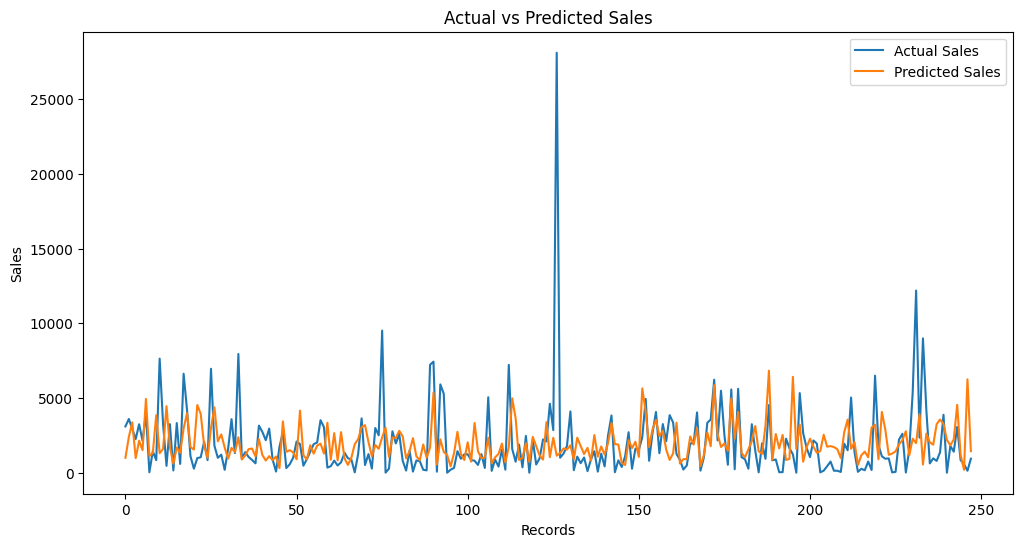

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Sales')
plt.plot(predictions, label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Records')
plt.ylabel('Sales')
plt.legend()

plt.show()

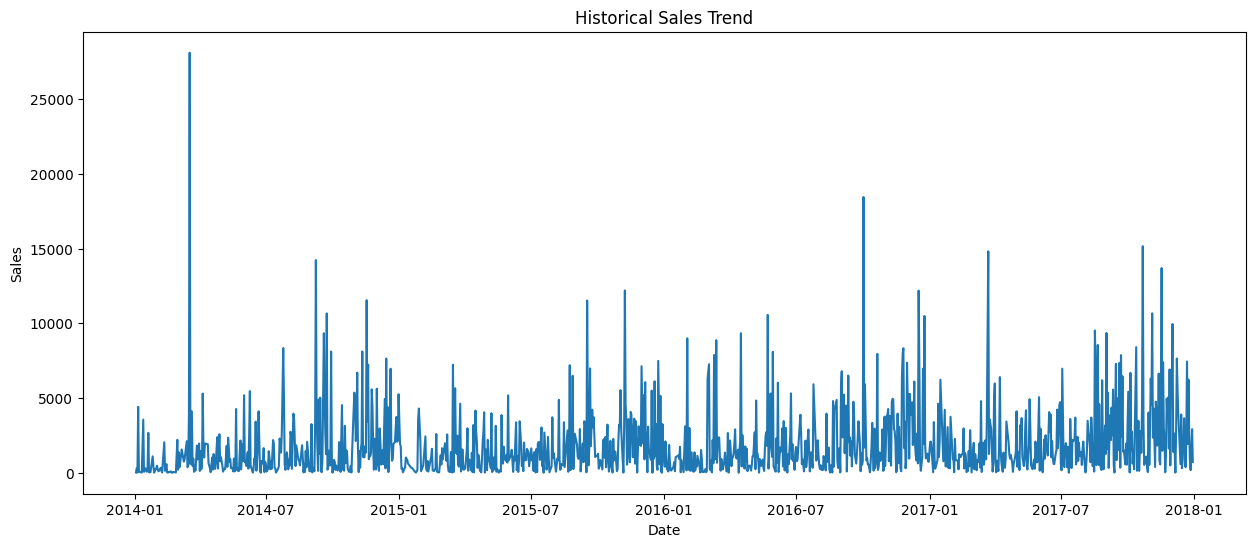

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    forecast_data['Order Date'],
    forecast_data['Sales']
)

plt.title('Historical Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

In [ ]:
future_dates = pd.date_range(
    start=forecast_data['Order Date'].max(),
    periods=31,
    freq='D'
)[1:]

future_df = pd.DataFrame()

future_df['Order Date'] = future_dates
future_df['Year'] = future_df['Order Date'].dt.year
future_df['Month'] = future_df['Order Date'].dt.month
future_df['Day'] = future_df['Order Date'].dt.day
future_df['DayOfWeek'] = future_df['Order Date'].dt.dayofweek
future_df['Quarter'] = future_df['Order Date'].dt.quarter

future_df['Predicted Sales'] = model.predict(
    future_df[['Year','Month','Day','DayOfWeek','Quarter']]
)

future_df.head()

,Order Date,Year,Month,Day,DayOfWeek,Quarter,Predicted Sales
0,2017-12-31,2017,12,31,6,4,1724.205671
1,2018-01-01,2018,1,1,0,1,2403.068415
2,2018-01-02,2018,1,2,1,1,1851.024815
3,2018-01-03,2018,1,3,2,1,1907.868990
4,2018-01-04,2018,1,4,3,1,1526.799240


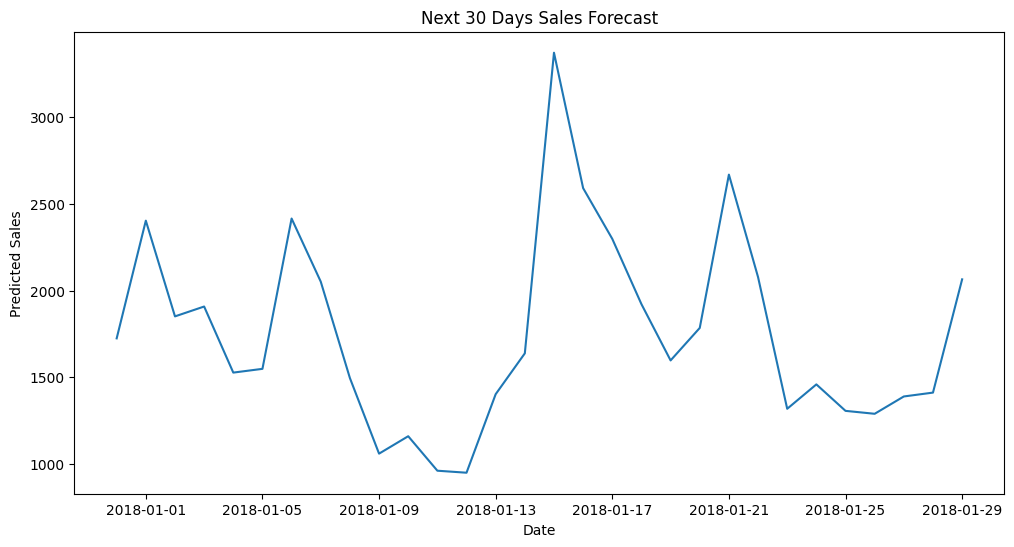

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    future_df['Order Date'],
    future_df['Predicted Sales']
)

plt.title('Next 30 Days Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Predicted Sales')

plt.show()